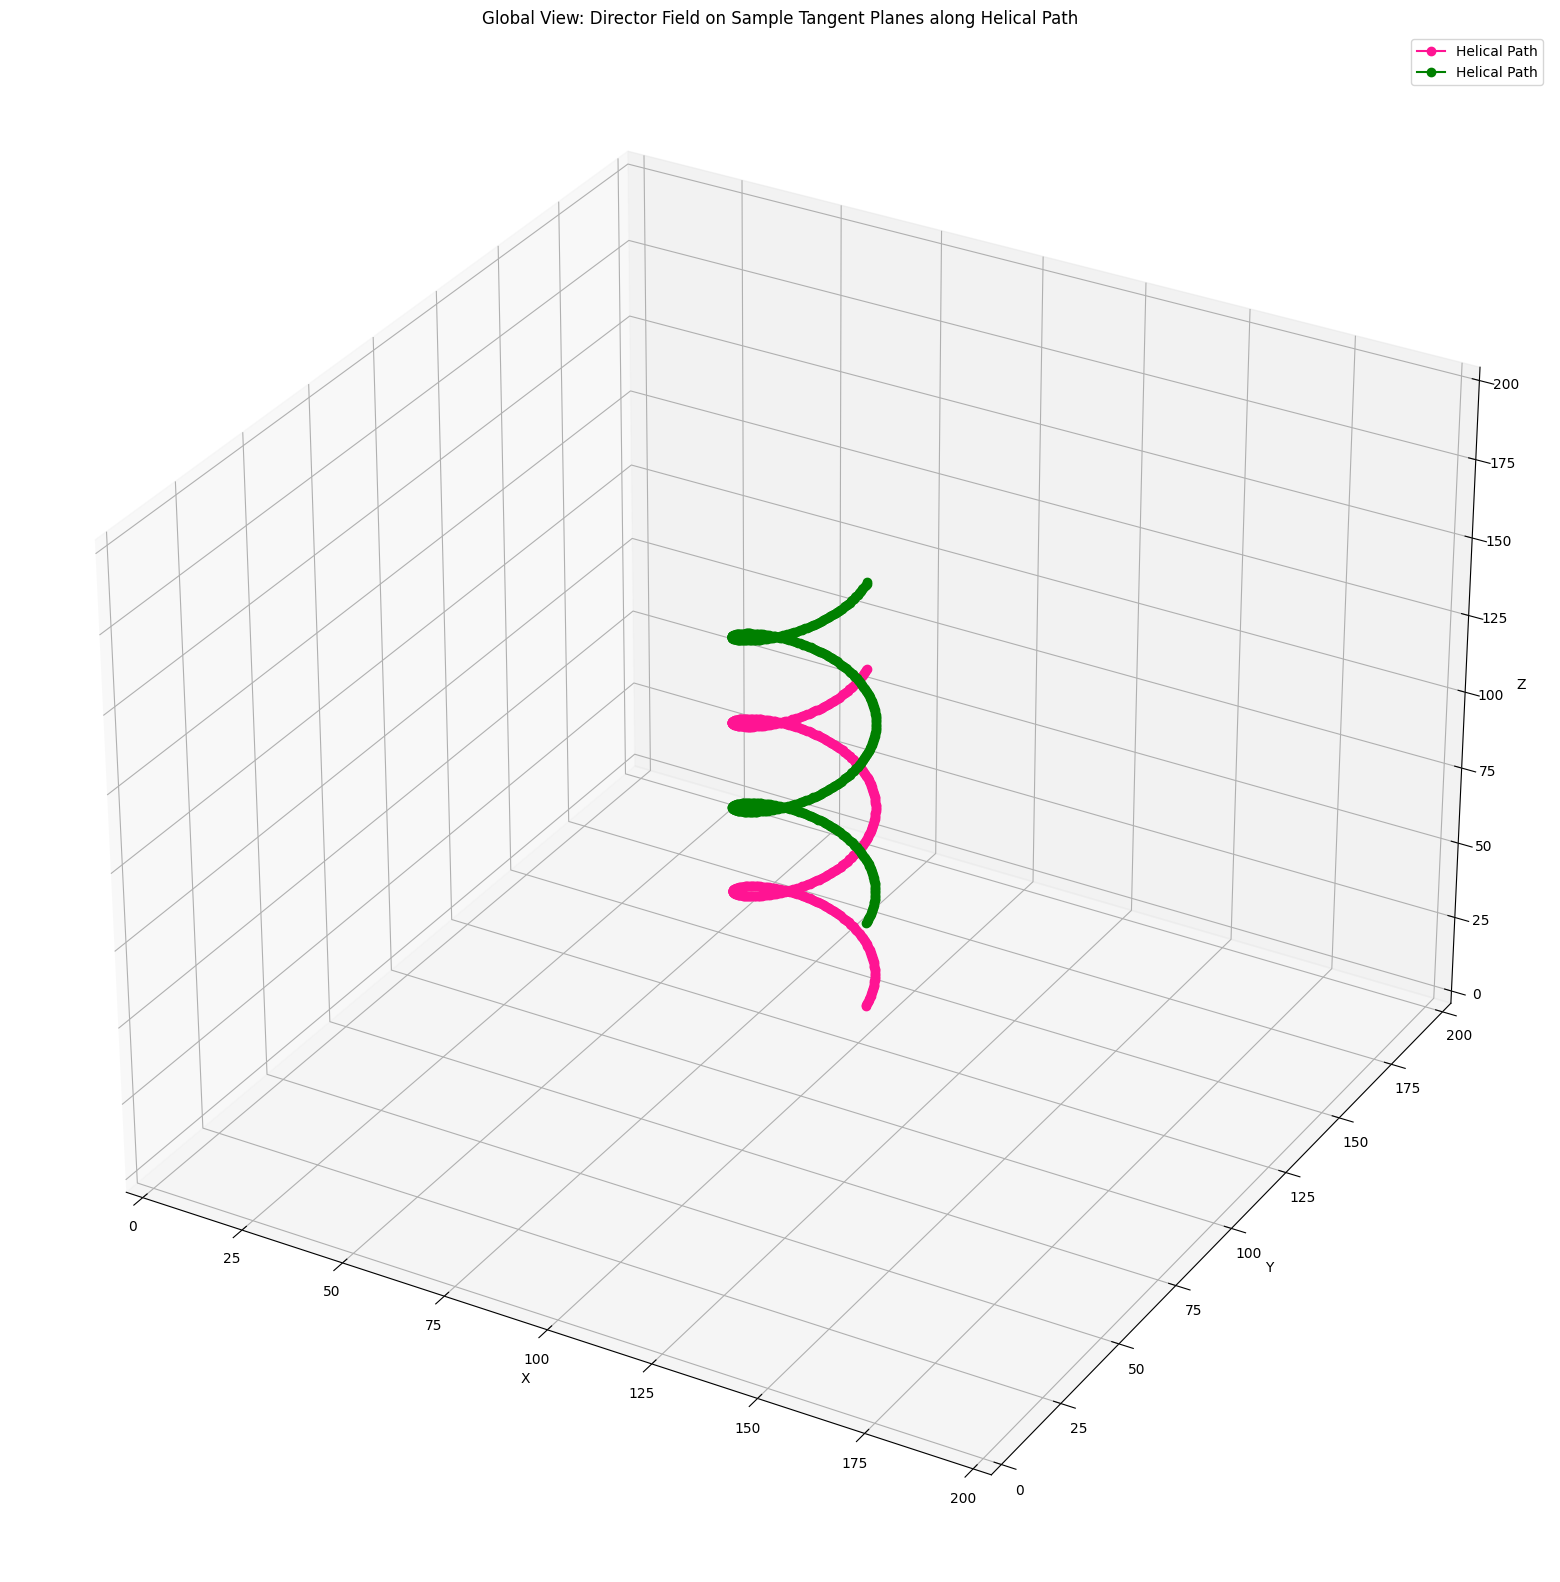

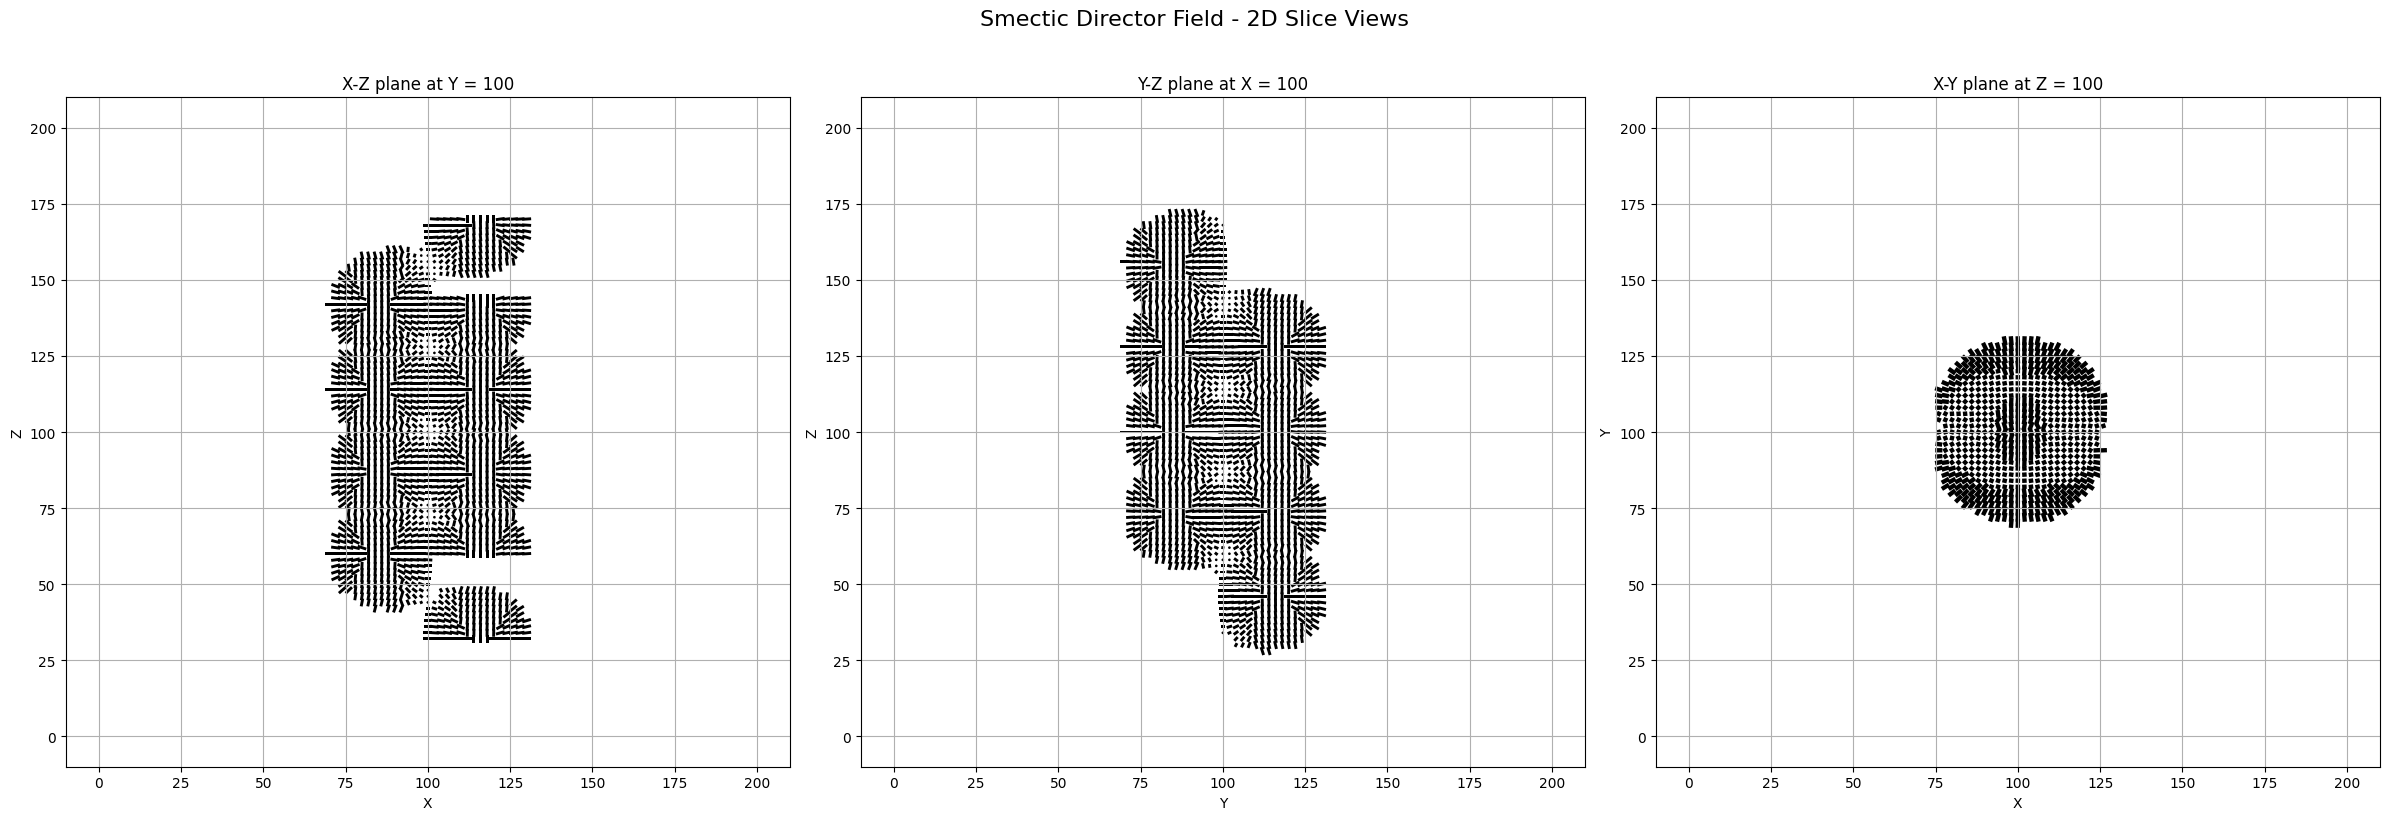

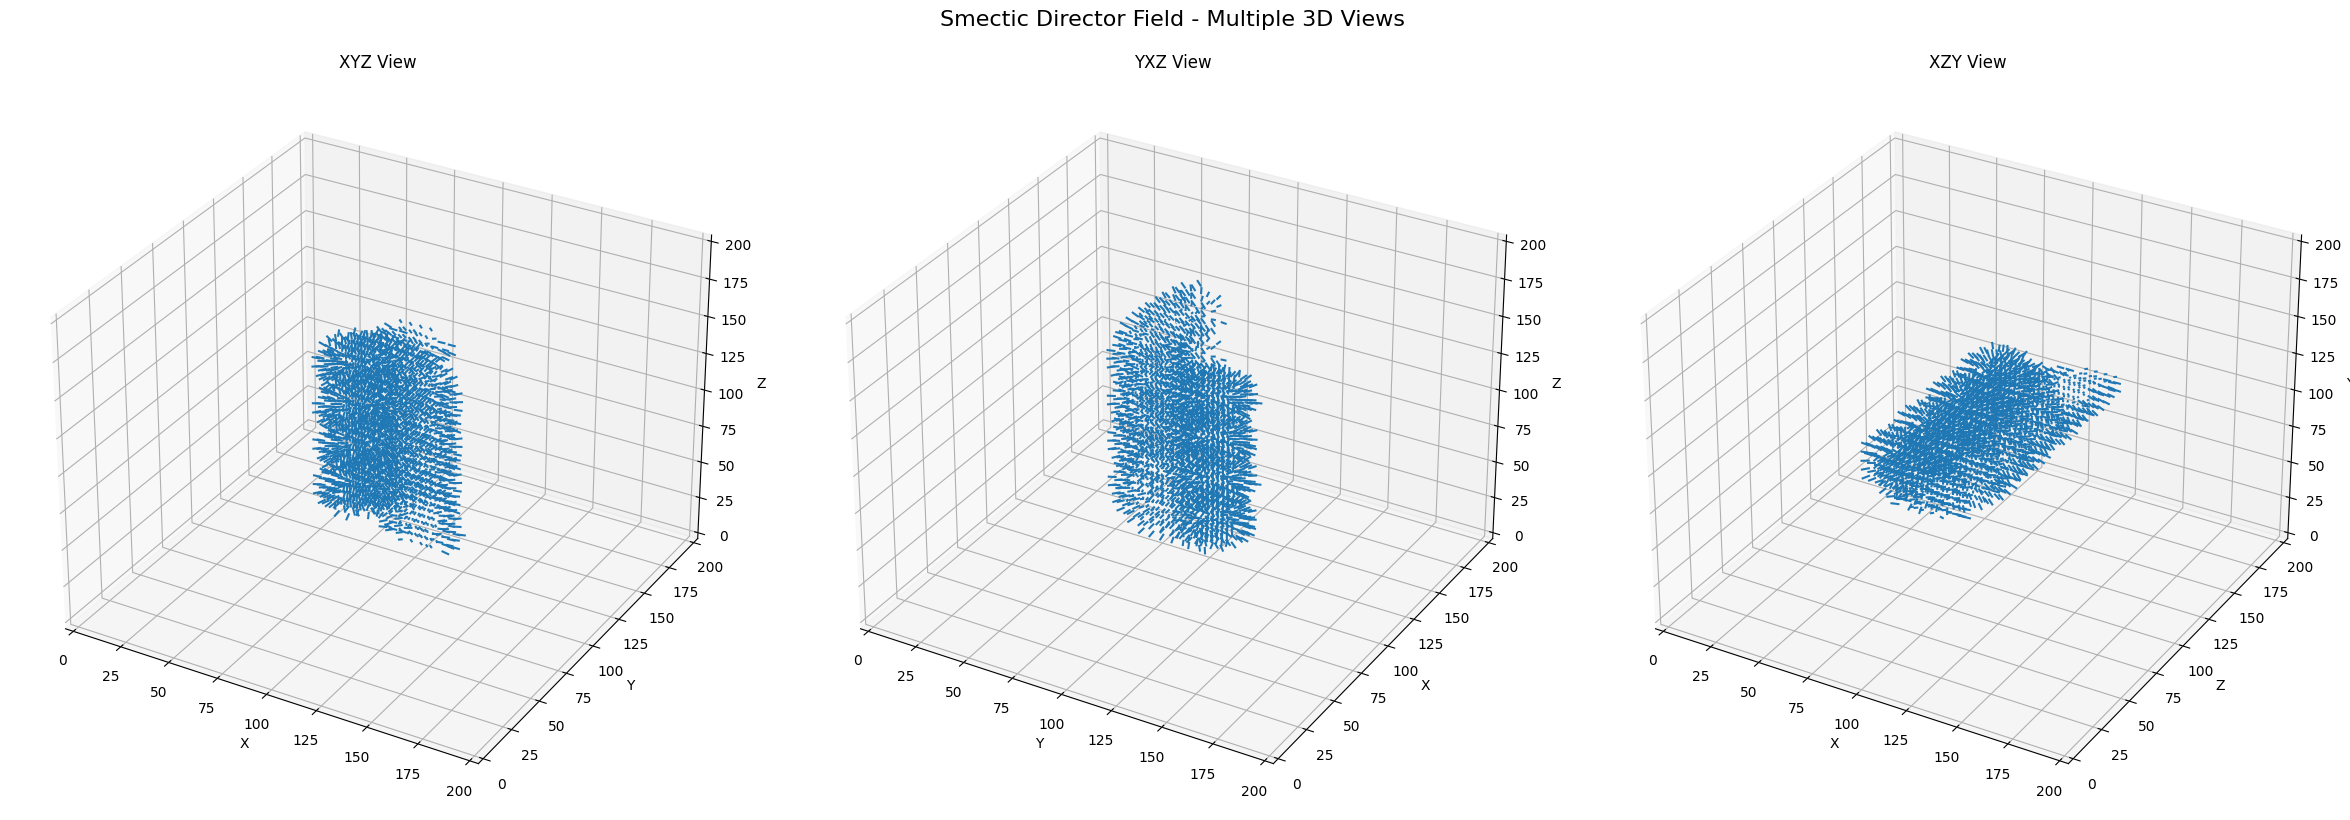

Saved: lc-pom/Interpolated_Director_Field/rotated_90_helix_L_201_r_15_pangle_59_np_500_re_0p7um.txt.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_80_helix_L_201_r_15_pangle_59_np_500_re_0p7um.txt.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_75_helix_L_201_r_15_pangle_59_np_500_re_0p7um.txt.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_60_helix_L_201_r_15_pangle_59_np_500_re_0p7um.txt.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_45_helix_L_201_r_15_pangle_59_np_500_re_0p7um.txt.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_30_helix_L_201_r_15_pangle_59_np_500_re_0p7um.txt.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_15_helix_L_201_r_15_pangle_59_np_500_re_0p7um.txt.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_10_helix_L_201_r_15_pangle_59_np_500_re_0p7um.txt.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_0_helix_L_201_r_15_pangle_59_np_500_re_0p7um.txt.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_90_helix_L_201_

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import cKDTree
import multiprocessing as mp
from scipy.ndimage import affine_transform


def create_director_circ_w_parabola_both_ways(X, Y, Z, nx, ny, nz, Cx, Cy, Cz, r, f):
    nx = nx.astype(np.float64)
    ny = ny.astype(np.float64)
    nz = nz.astype(np.float64)
    
    # Compute squared radial distance from cylinder center in XY-plane
    distances_squared = (X - Cx)**2 + (Y - Cy)**2
    distances = np.sqrt(distances_squared)
    
    # Mask for points within the circular cross-section
    mask_circ = (distances <= r)
    # Prevent zero distances (on axis) from causing division errors
    distances = np.where(distances < 1e-6, 1e-6, distances)
    
    # Parabolic masks above and below centerline in Y-direction
    parabola_mask1 = (4 * f * (Y - Cy + f)) >= (X - Cx)**2
    parabola_mask2 = (4 * f * (Cy - Y + f)) >= (X - Cx)**2
    
    # Combine to find inside/outside the parabola region
    inside_parabola  = mask_circ & (parabola_mask1 | parabola_mask2)
    outside_parabola = mask_circ & ~(parabola_mask1 | parabola_mask2)
    
    # Inside parabola: set director purely vertical in +Y direction
    nx[inside_parabola] = 0
    ny[inside_parabola] = 1
    nz[inside_parabola] = 0
    
    # Outside parabola: compute radial director in XY-plane
    x_val = (X[outside_parabola] - Cx) / distances[outside_parabola]
    y_val = (Y[outside_parabola] - Cy) / distances[outside_parabola]
    nx[outside_parabola] = x_val
    ny[outside_parabola] = y_val
    nz[outside_parabola] = 0
    
    return nx, ny, nz


def create_double_parabola_circles(X, Y, Z, nx, ny, nz, center, r, distance, f):
    Cx, Cy, Cz = center
    # Compute Y-centers for two circles separated by 'distance'
    Cy1 = Cy - distance / 2
    Cy2 = Cy + distance / 2
    
    # Apply parabola director generation for each circle
    nx, ny, nz = create_director_circ_w_parabola_both_ways(
        X, Y, Z,
        nx, ny, nz,
        Cx, Cy, Cz,
        r, f
    )
    return nx, ny, nz

def create_helical_path(center, q, num_points, num_turns, P):
    Cx, Cy, Cz = center

    # Parameter theta spans num_turns revolutions
    theta = np.linspace(0, 2 * np.pi * num_turns, num_points)
    
    
    # Parametric equations for a helix
    X = Cx + q * np.cos(theta)
    Y = Cy + q * np.sin(theta)
    Z = Cz + (P / (2 * np.pi)) * theta
    

    return X, Y, Z, theta

def create_tangent_vectors(center, theta, q, P):
    """
    Compute unit tangent vectors along helix path.
    Parameters:
      center: 3-element tuple, unused here but retained for signature
      theta: array of helix parameters
      q: helix radius
      P: helix pitch (distance per full 2π)
    Returns:
      tangent_x, tangent_y, tangent_z arrays
    """
    # Compute derivatives of helix parametric eqns
    dx_dtheta = -q * np.sin(theta)
    dy_dtheta =  q * np.cos(theta)
    dz_dtheta =  (P / (2 * np.pi)) * np.ones_like(theta)

    # Compute norm of tangent vector at each point
    norm = np.sqrt(dx_dtheta**2 + dy_dtheta**2 + dz_dtheta**2)
    norm[norm == 0] = 1

    # Normalize components to unit length
    tangent_x = dx_dtheta / norm
    tangent_y = dy_dtheta / norm
    tangent_z = dz_dtheta / norm

    return tangent_x, tangent_y, tangent_z

def compute_local_frame(T):
    """
    Build orthonormal frame (u, v) perpendicular to tangent T.
    """
    T = T / np.linalg.norm(T)  # unit tangent
    # Choose arbitrary vector not parallel to T
    if abs(T[2]) < 0.99:
        arbitrary = np.array([0, 0, 1.0])
    else:
        arbitrary = np.array([0, 1.0, 0])
    # First perpendicular vector
    u = np.cross(arbitrary, T)
    u /= np.linalg.norm(u)
    # Second perpendicular vector via cross product
    v = np.cross(T, u)
    return u, v


def find_distance_of_filament(r, tilda_R_not):
    # Compute separation distance of double-parabola centers
    return (2 * r) * (1 - tilda_R_not)


def interpolate_single_slice(args):
    """
    Worker function for multiprocessing: interpolate a single Z-slice from scattered data.
    """
    k, Lx, Ly, Lz, tree, final_vectors, max_distance = args
    Xg, Yg = np.meshgrid(np.arange(Lx), np.arange(Ly), indexing='ij')
    Zg = np.full_like(Xg, k)
    grid_coords = np.stack((Xg, Yg, Zg), axis=-1).reshape(-1, 3)

    dist, idx = tree.query(grid_coords, k=1)
    vecs = final_vectors[idx].copy()
    vecs[dist > max_distance] = 0

    return vecs.reshape(Xg.shape[0], Xg.shape[1], 3).astype(np.float32)


def rotate_volume_and_vectors(nx, ny, nz, R):
    # Invert rotation for affine transform of volumes
    invR = np.linalg.inv(R)
    center = np.array(nx.shape)/2  # center of volume
    def xf(arr):
        return affine_transform(
            arr,
            matrix=invR,
            offset=center-invR@center,
            order=1,
            mode='nearest'
        )
    # Apply to each director component
    nxr, nyr, nzr = xf(nx), xf(ny), xf(nz)
    # Reassemble vector and apply forward rotation
    dirs = np.stack((nxr, nyr, nzr), axis=-1)
    out = dirs @ R.T
    return out[...,0], out[...,1], out[...,2]

def export_directors(X, Y, Z,
                     nx, ny, nz,
                     dx, dy, dz,
                     outdir, prefix):
    # Prepare headers describing grid dimensions and spacing
    hdr1 = f"{X.shape[0]} {Y.shape[1]} {Z.shape[2]} {dx:.2f} {dy:.2f} {dz:.2f}"
    hdr2 = f"0 {X.shape[0]-1} 0 {Y.shape[1]-1} 0 {Z.shape[2]-1}"
    # Flatten and stack for saving or printing
    data = np.vstack([
        X.ravel(), Y.ravel(), Z.ravel(),
        nx.ravel(), ny.ravel(), nz.ravel()
    ]).T
    path = os.path.join(outdir, f"{prefix}.txt")
    # Printing path for debugging; file writing lines commented out
    print(f"Saved: {path}")



def main():
    # Grid and filament parameters
    Lx = Ly = Lz = 201
    r = 15
    tilda_R_not = 0.21
    f = (tilda_R_not * r) / 2
    d = find_distance_of_filament(r, tilda_R_not)

    theta_pitch = np.radians(60)
    P = 2 * d / np.sin(theta_pitch)
    q = (P * np.tan(theta_pitch)) / (2 * np.pi)
    helix_turns = 2
    num_points = 500

    # Define total helix height so that h is known
    h = helix_turns * P

    global_center_1 = np.array([Lx/2, Ly/2, (Lz/2) - (P/4) - (h/2)])
    global_center_2 = np.array([Lx/2, Ly/2, (Lz/2) - (P/4) - (h/2) + (P/2)])

    # Compute helical path points and tangent vectors
    X_path_1, Y_path_1, Z_path_1, theta_path_1 = create_helical_path(global_center_1, q, num_points, helix_turns, P)
    tangent_x_1, tangent_y_1, tangent_z_1 = create_tangent_vectors(global_center_1, theta_path_1, q , P)

    X_path_2, Y_path_2, Z_path_2, theta_path_2 = create_helical_path(global_center_2, q, num_points, helix_turns, P)
    tangent_x_2, tangent_y_2, tangent_z_2 = create_tangent_vectors(global_center_2, theta_path_2, q, P)

    # Collect scattered director samples in local tangent planes
    all_global_points  = []
    all_global_vectors = []

    local_range = 4 * r
    plane_res   = int(2 * local_range) + 1
    coords      = np.linspace(-local_range, local_range, plane_res)
    X_local, Y_local = np.meshgrid(coords, coords, indexing='ij')
    Z_local         = np.zeros_like(X_local)

    for X_path, Y_path, Z_path, tx, ty, tz in [
        (X_path_1, Y_path_1, Z_path_1, tangent_x_1, tangent_y_1, tangent_z_1),
        (X_path_2, Y_path_2, Z_path_2, tangent_x_2, tangent_y_2, tangent_z_2),
    ]:
        for i in range(len(X_path)):
            origin = np.array([X_path[i], Y_path[i], Z_path[i]])
            T      = np.array([tx[i],    ty[i],    tz[i]])
            u, v   = compute_local_frame(T)

            # Initialize local director arrays with NaNs
            nx_l = np.full_like(X_local, np.nan)
            ny_l = np.full_like(Y_local, np.nan)
            nz_l = np.full_like(Z_local, np.nan)

            # Populate local director field via parabola circle
            nx_l, ny_l, nz_l = create_double_parabola_circles(
                X_local, Y_local, Z_local,
                nx_l,     ny_l,     nz_l,
                (0,0,0),  r,        d,        f
            )

            # Extract valid points and vectors (non-NaN)
            mask      = ~np.isnan(nx_l)
            valid_X   = X_local[mask]
            valid_Y   = Y_local[mask]
            valid_nx  = nx_l[mask]
            valid_ny  = ny_l[mask]

            # Map local plane samples into global coordinates
            points  = origin + valid_X[:,None]*u + valid_Y[:,None]*v
            vectors = valid_nx[:,None]*u      + valid_ny[:,None]*v

            all_global_points .append(points)
            all_global_vectors.append(vectors)

          
    # --------- Visualization of scatter fields ----------  
    fig = plt.figure(figsize=(24,20))
    ax = fig.add_subplot(111, projection='3d')

    n_p = 50  # Plot every nth tangent plane
    sample_rate = 1  # adjust for clarity


    # Plot the entire helical path for context
    ax.plot(
        X_path_1, Y_path_1, Z_path_1, 'o-',
        color='deeppink', label='Helical Path'
    )

    # Plot the entire helical path for context
    ax.plot(
        X_path_2, Y_path_2, Z_path_2, 'o-',
        color='green', label='Helical Path'
    )

    ax.set_title(
        "Global View: Director Field on Sample Tangent Planes along Helical Path"
    )
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_xlim([0, 400/2])
    ax.set_ylim([0, 400/2])
    ax.set_zlim([0, 400/2])
    ax.legend()
    plt.show()

    # --------- Interpolation to regular grid ----------
    final_points = np.vstack(all_global_points); final_vectors = np.vstack(all_global_vectors)
    final_points = np.nan_to_num(final_points); final_vectors = np.nan_to_num(final_vectors)
    tree = cKDTree(final_points); max_distance = 1
    pool_args = [(k, Lx, Ly, Lz, tree, final_vectors, max_distance) for k in range(Lz)]

    with mp.get_context("fork").Pool(2) as pool:
        director_slices = pool.map(interpolate_single_slice, pool_args)
    director = np.stack(director_slices, axis=2)
    nx, ny, nz = director[...,0], director[...,1], director[...,2]
    
    # Prepare meshgrid for plotting
    Xg, Yg, Zg = np.meshgrid(np.arange(Lx), np.arange(Ly), np.arange(Lz), indexing='ij')

    # --------- 2D slice visualization ----------
    scale1 = scale2 = scale3 = 80
    width1 = width2 = 0.004
    width3 = 0.006
    headaxislength = 0
    headlength = 0
    headwidth = 1
    k1 = k2 = k3 = 2
    y_display = 100
    x_display = 100
    z_display = 100

    # Prepare masked copies for 2D slices
    nx_p1, nz_p1 = nx.copy(), nz.copy()
    mask1 = (nx_p1 == 0) & (nz_p1 == 0)
    nx_p1[mask1], nz_p1[mask1] = np.nan, np.nan

    ny_p2, nz_p2 = ny.copy(), nz.copy()
    mask2 = (ny_p2 == 0) & (nz_p2 == 0)
    ny_p2[mask2], nz_p2[mask2] = np.nan, np.nan

    nx_p3, ny_p3 = nx.copy(), ny.copy()
    mask3 = (nx_p3 == 0) & (ny_p3 == 0)
    nx_p3[mask3], ny_p3[mask3] = np.nan, np.nan

    # 2D slice plots
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle('Smectic Director Field - 2D Slice Views', fontsize=16, y=1.02)
    axes[0].quiver(Xg[::k1, y_display, ::k1], Zg[::k1, y_display, ::k1],
                   nx_p1[::k1, y_display, ::k1], nz_p1[::k1, y_display, ::k1],
                   pivot='middle', scale=scale1, width=width1,
                   headaxislength=headaxislength, headlength=headlength, headwidth=headwidth)
    axes[0].set_title(f'X-Z plane at Y = {y_display}')
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Z'); axes[0].grid()

    axes[1].quiver(Yg[x_display, ::k2, ::k2], Zg[x_display, ::k2, ::k2],
                   ny_p2[x_display, ::k2, ::k2], nz_p2[x_display, ::k2, ::k2],
                   pivot='middle', scale=scale2, width=width2,
                   headaxislength=headaxislength, headlength=headlength, headwidth=headwidth)
    axes[1].set_title(f'Y-Z plane at X = {x_display}')
    axes[1].set_xlabel('Y'); axes[1].set_ylabel('Z'); axes[1].grid()

    axes[2].quiver(Xg[::k3, ::k3, z_display], Yg[::k3, ::k3, z_display],
                   nx_p3[::k3, ::k3, z_display], ny_p3[::k3, ::k3, z_display],
                   pivot='middle', scale=scale3, width=width3,
                   headaxislength=headaxislength, headlength=headlength, headwidth=headwidth)
    axes[2].set_title(f'X-Y plane at Z = {z_display}')
    axes[2].set_xlabel('X'); axes[2].set_ylabel('Y'); axes[2].grid()

    plt.tight_layout(); plt.show()

    # 3D quiver views
    s = 5; length = 4; arrow_length_ratio = 0
    fig = plt.figure(figsize=(24, 8))
    fig.suptitle('Smectic Director Field - Multiple 3D Views', fontsize=16, y=1.02)

    ax1 = fig.add_subplot(131, projection='3d')
    ax1.quiver(Xg[::s, ::s, ::s], Yg[::s, ::s, ::s], Zg[::s, ::s, ::s], 
               nx[::s, ::s, ::s], ny[::s, ::s, ::s], nz[::s, ::s, ::s], 
               length=length, arrow_length_ratio=arrow_length_ratio)
    ax1.set_title('XYZ View'); ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    ax1.set_xlim([0, Lx-1]); ax1.set_ylim([0, Ly-1]); ax1.set_zlim([0, Lz-1])

    ax2 = fig.add_subplot(132, projection='3d')
    ax2.quiver(Yg[::s, ::s, ::s], Xg[::s, ::s, ::s], Zg[::s, ::s, ::s], 
               ny[::s, ::s, ::s], nx[::s, ::s, ::s], nz[::s, ::s, ::s], 
               length=length, arrow_length_ratio=arrow_length_ratio)
    ax2.set_title('YXZ View'); ax2.set_xlabel('Y'); ax2.set_ylabel('X'); ax2.set_zlabel('Z')
    ax2.set_xlim([0, Lx-1]); ax2.set_ylim([0, Ly-1]); ax2.set_zlim([0, Lz-1])

    ax3 = fig.add_subplot(133, projection='3d')
    ax3.quiver(Xg[::s, ::s, ::s], Zg[::s, ::s, ::s], Yg[::s, ::s, ::s], 
               nx[::s, ::s, ::s], nz[::s, ::s, ::s], ny[::s, ::s, ::s], 
               length=length, arrow_length_ratio=arrow_length_ratio)
    ax3.set_title('XZY View'); ax3.set_xlabel('X'); ax3.set_ylabel('Z'); ax3.set_zlabel('Y')
    ax3.set_xlim([0, Lx-1]); ax3.set_ylim([0, Ly-1]); ax3.set_zlim([0, Lz-1])

    plt.tight_layout(); plt.show()
    
    X, Y, Z = np.meshgrid(np.arange(Lx), np.arange(Ly), np.arange(Lz), indexing='ij')
    # Export filenames only
    r_e_values = np.array([0.7,1.0])*1e-6
    theta_vals = [90,80,75,60,45,30,15,10,0]
    outdir = "lc-pom/Interpolated_Director_Field"
    L_str, r_val, p_val, np_val = Lx, r, int(np.degrees(theta_pitch)), 500
    for r_e in r_e_values:
        res = r_e/r; d_pom = round(res*1e6,2)
        dx=dy=dz=d_pom
        for theta in theta_vals:
            Rx = np.array([[1,0,0],[0,np.cos(np.radians(theta)),-np.sin(np.radians(theta))],[0,np.sin(np.radians(theta)),np.cos(np.radians(theta))]])
            nx_r, ny_r, nz_r = rotate_volume_and_vectors(nx, ny, nz, Rx)
            re_str = f"{r_e*1e6:.1f}".replace('.', 'p')
            prefix = f"rotated_{theta}_helix_L_{L_str}_r_{r_val}_pangle_{p_val}_np_{np_val}_re_{re_str}um.txt"
            export_directors(X, Y, Z, nx_r, ny_r, nz_r, dx, dy, dz, outdir, prefix)



if __name__ == "__main__":
    main()